<a href="https://colab.research.google.com/github/rmohitraj/Part-3-Churn-Prediction-Model-Model-Card/blob/main/churn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Prepare Modeling Data

### Subtask:
Load the 'rfm_modeling_snapshot.csv' file, perform an initial inspection, and ensure no data leakage.

In [21]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Capstone Project/d2c churn data package/rfm_modeling_snapshot.csv')

# Display the first few rows
print("DataFrame Head:")
print(df.head())

# Display the shape of the DataFrame
print("\nDataFrame Shape:")
print(df.shape)

# Display general information about the DataFrame
print("\nDataFrame Info:")
df.info()

DataFrame Head:
  customer_id snapshot_date city_tier age_group acquisition_channel  \
0   CUST00001    2025-09-30    Tier 1     18-24           Instagram   
1   CUST00002    2025-09-30    Tier 2     25-34         Marketplace   
2   CUST00003    2025-09-30    Tier 1     25-34          Influencer   
3   CUST00004    2025-09-30    Tier 3     25-34       Google Search   
4   CUST00005    2025-09-30    Tier 3     35-44             Organic   

  loyalty_tier preferred_category marketing_consent  recency_days  \
0       Silver             Makeup               Yes           107   
1       Silver          Hair Care               Yes            40   
2          NaN          Skin Care               Yes           171   
3          NaN          Fragrance                No           131   
4         Gold          Hair Care               Yes            38   

   frequency_180d  ...  sessions_30d  product_views_30d  cart_adds_30d  \
0               1  ...             1                  4             

In [5]:
import pandas as pd

# Correct the file path based on the plan
file_path = '/content/drive/MyDrive/Capstone Project/d2c churn data package/rfm_modeling_snapshot.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Display the first few rows
print("DataFrame Head:")
print(df.head())

# Display the shape of the DataFrame
print("\nDataFrame Shape:")
print(df.shape)

# Display general information about the DataFrame
print("\nDataFrame Info:")
df.info()

DataFrame Head:
  customer_id snapshot_date city_tier age_group acquisition_channel  \
0   CUST00001    2025-09-30    Tier 1     18-24           Instagram   
1   CUST00002    2025-09-30    Tier 2     25-34         Marketplace   
2   CUST00003    2025-09-30    Tier 1     25-34          Influencer   
3   CUST00004    2025-09-30    Tier 3     25-34       Google Search   
4   CUST00005    2025-09-30    Tier 3     35-44             Organic   

  loyalty_tier preferred_category marketing_consent  recency_days  \
0       Silver             Makeup               Yes           107   
1       Silver          Hair Care               Yes            40   
2          NaN          Skin Care               Yes           171   
3          NaN          Fragrance                No           131   
4         Gold          Hair Care               Yes            38   

   frequency_180d  ...  sessions_30d  product_views_30d  cart_adds_30d  \
0               1  ...             1                  4             

In [6]:
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Missing values per column:
customer_id                    0
snapshot_date                  0
city_tier                      0
age_group                      0
acquisition_channel            0
loyalty_tier                1386
preferred_category             0
marketing_consent              0
recency_days                   0
frequency_180d                 0
monetary_180d                  0
return_rate_180d               0
avg_discount_pct_180d          0
avg_rating_180d                0
category_diversity_180d        0
ticket_count_90d               0
negative_ticket_rate_90d       0
avg_resolution_hours_90d       0
days_since_signup              0
sessions_30d                   0
product_views_30d              0
cart_adds_30d                  0
wishlist_adds_30d              0
abandoned_carts_30d            0
email_opens_30d                0
campaign_clicks_30d            0
last_visit_days_ago            0
churn_next_60d                 0
split                          0
dtype: int64

N

In [7]:
df['loyalty_tier'].fillna('Unknown', inplace=True)

print("\nMissing values per column after handling loyalty_tier:")
print(df.isnull().sum())


Missing values per column after handling loyalty_tier:
customer_id                 0
snapshot_date               0
city_tier                   0
age_group                   0
acquisition_channel         0
loyalty_tier                0
preferred_category          0
marketing_consent           0
recency_days                0
frequency_180d              0
monetary_180d               0
return_rate_180d            0
avg_discount_pct_180d       0
avg_rating_180d             0
category_diversity_180d     0
ticket_count_90d            0
negative_ticket_rate_90d    0
avg_resolution_hours_90d    0
days_since_signup           0
sessions_30d                0
product_views_30d           0
cart_adds_30d               0
wishlist_adds_30d           0
abandoned_carts_30d         0
email_opens_30d             0
campaign_clicks_30d         0
last_visit_days_ago         0
churn_next_60d              0
split                       0
dtype: int64


/tmp/ipykernel_2998/523244397.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loyalty_tier'].fillna('Unknown', inplace=True)


In [8]:
df['loyalty_tier'] = df['loyalty_tier'].fillna('Unknown')

print("\nMissing values per column after handling loyalty_tier:")
print(df.isnull().sum())


Missing values per column after handling loyalty_tier:
customer_id                 0
snapshot_date               0
city_tier                   0
age_group                   0
acquisition_channel         0
loyalty_tier                0
preferred_category          0
marketing_consent           0
recency_days                0
frequency_180d              0
monetary_180d               0
return_rate_180d            0
avg_discount_pct_180d       0
avg_rating_180d             0
category_diversity_180d     0
ticket_count_90d            0
negative_ticket_rate_90d    0
avg_resolution_hours_90d    0
days_since_signup           0
sessions_30d                0
product_views_30d           0
cart_adds_30d               0
wishlist_adds_30d           0
abandoned_carts_30d         0
email_opens_30d             0
campaign_clicks_30d         0
last_visit_days_ago         0
churn_next_60d              0
split                       0
dtype: int64


In [9]:
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

print("Data types after converting snapshot_date:")
print(df['snapshot_date'].dtype)


Data types after converting snapshot_date:
datetime64[ns]


```markdown
### Data Leakage Prevention Strategy

To prevent data leakage, especially crucial in churn prediction, the following strategies have been considered and will be adhered to throughout the modeling process:

1.  **Time-based Split**: The dataset already contains a `split` column ('train', 'validation', 'test') which we assume is a time-based split, where the training data precedes the validation and test data chronologically. This ensures that the model is trained only on past information to predict future churn, mimicking real-world deployment scenarios.

2.  **Feature Engineering**: When creating new features, we must ensure that these features are derived only from data available *before* the `snapshot_date` for each customer. For example, if we were to calculate 'average purchase value', it would only include purchases made up to the `snapshot_date`.

3.  **Target Variable Definition**: The `churn_next_60d` target variable explicitly indicates churn within the *next* 60 days *after* the `snapshot_date`. This definition naturally prevents leakage as the target is based on future events relative to the feature set.

By carefully managing the time aspect of the data, we aim to build a robust model that generalizes well to new, unseen customer data.
```

## Data Splitting

### Subtask:
Separate the prepared data into training, validation, and test sets using the existing 'split' column, and justify this splitting strategy.

In [10]:
train_df = df[df['split'] == 'train'].copy()
val_df = df[df['split'] == 'validation'].copy()
test_df = df[df['split'] == 'test'].copy()

print("Shape of train_df:", train_df.shape)
print("Shape of val_df:", val_df.shape)
print("Shape of test_df:", test_df.shape)

Shape of train_df: (1728, 29)
Shape of val_df: (336, 29)
Shape of test_df: (336, 29)


```markdown
### Justification for Data Splitting Strategy

The chosen data splitting strategy utilizes the pre-defined `split` column (train, validation, test) in the dataset. This approach is critical for churn prediction, as it represents a **time-based split**.

In real-world churn prediction scenarios, we train models on historical data to predict future churn. A random split would mix past and future data, leading to **data leakage** and overly optimistic performance estimates. By using a time-based split where the training data precedes the validation and test data chronologically, we simulate the actual deployment environment:

*   **Training Set**: Contains customer data and churn outcomes from an earlier period.
*   **Validation Set**: Contains customer data and churn outcomes from a subsequent period, used for hyperparameter tuning and model selection.
*   **Test Set**: Contains customer data and churn outcomes from the most recent period, used for final, unbiased model performance evaluation.

This method ensures that the model learns patterns from past customer behavior to predict churn in future, unseen periods, making the model's performance metrics a more reliable indicator of its real-world effectiveness.
```

## Train Simple Baseline Model

### Subtask:
Train a simple baseline classification model (e.g., Logistic Regression or Decision Tree) on the training data to establish a performance benchmark for churn prediction.

In [11]:
TARGET_COLUMN = 'churn_next_60d'
EXCLUDE_COLUMNS = ['customer_id', 'snapshot_date', 'split']

FEATURE_COLUMNS = [col for col in df.columns if col not in [TARGET_COLUMN] + EXCLUDE_COLUMNS]

print(f"Target Column: {TARGET_COLUMN}")
print(f"Number of Feature Columns: {len(FEATURE_COLUMNS)}")
print(f"First 5 Feature Columns: {FEATURE_COLUMNS[:5]}")

Target Column: churn_next_60d
Number of Feature Columns: 25
First 5 Feature Columns: ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category']


In [12]:
X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET_COLUMN]

X_val = val_df[FEATURE_COLUMNS]
y_val = val_df[TARGET_COLUMN]

X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET_COLUMN]

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1728, 25)
Shape of y_train: (1728,)
Shape of X_val: (336, 25)
Shape of y_val: (336,)
Shape of X_test: (336, 25)
Shape of y_test: (336,)


In [13]:
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Apply one-hot encoding using get_dummies
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Ensure all splits have the same columns (important for consistent feature sets)
X_train_cols = set(X_train_encoded.columns)
X_val_cols = set(X_val_encoded.columns)
X_test_cols = set(X_test_encoded.columns)

all_cols = sorted(list(X_train_cols.union(X_val_cols).union(X_test_cols)))

X_train_encoded = X_train_encoded.reindex(columns=all_cols, fill_value=0)
X_val_encoded = X_val_encoded.reindex(columns=all_cols, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=all_cols, fill_value=0)


print("Shape of X_train_encoded:", X_train_encoded.shape)
print("Shape of X_val_encoded:", X_val_encoded.shape)
print("Shape of X_test_encoded:", X_test_encoded.shape)

Shape of X_train_encoded: (1728, 38)
Shape of X_val_encoded: (336, 38)
Shape of X_test_encoded: (336, 38)


In [14]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set solver to 'liblinear' for better performance on smaller datasets and for L1/L2 regularization
# Set random_state for reproducibility
model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model on the encoded training data
model.fit(X_train_encoded, y_train)

print("Logistic Regression baseline model trained successfully!")

Logistic Regression baseline model trained successfully!


## Train Stronger Model

### Subtask:
Train a stronger classification model (e.g., Random Forest, Gradient Boosting like XGBoost or LightGBM, or another justified classifier) on the training data for churn prediction.

In [15]:
from lightgbm import LGBMClassifier

# Initialize the LightGBM Classifier model
# Using 'binary' objective for binary classification and 'auc' metric for evaluation
# Set random_state for reproducibility
model_stronger = LGBMClassifier(objective='binary', metric='auc', random_state=42)

# Train the model on the encoded training data
model_stronger.fit(X_train_encoded, y_train)

print("LightGBM stronger model trained successfully!")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 812, number of negative: 916
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000538 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1285
[LightGBM] [Info] Number of data points in the train set: 1728, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.469907 -> initscore=-0.120516
[LightGBM] [Info] Start training from score -0.120516
LightGBM stronger model trained successfully!


## Model Evaluation

### Subtask:
Evaluate both the baseline and stronger models using appropriate metrics for churn classification. This includes Precision, Recall, F1-score, ROC-AUC or PR-AUC curves, and confusion matrices. Provide legends to the visualizations.

Baseline Model (Logistic Regression) Evaluation on Validation Set:
Accuracy: 0.8125
Precision: 0.8043
Recall: 0.7551
F1-Score: 0.7789
ROC-AUC: 0.8834


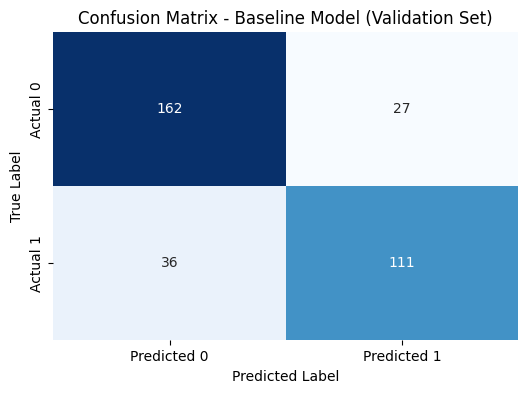

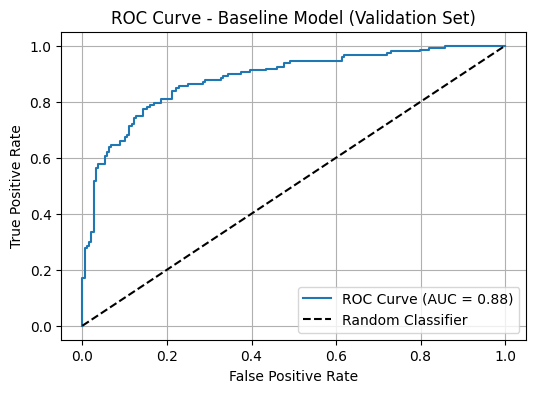

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Baseline Model Evaluation (Logistic Regression) ---

# Predict probabilities and classes on the validation set
y_pred_baseline = model.predict(X_val_encoded)
y_prob_baseline = model.predict_proba(X_val_encoded)[:, 1]

# Calculate metrics
accuracy_baseline = accuracy_score(y_val, y_pred_baseline)
precision_baseline = precision_score(y_val, y_pred_baseline)
recall_baseline = recall_score(y_val, y_pred_baseline)
f1_baseline = f1_score(y_val, y_pred_baseline)
roc_auc_baseline = roc_auc_score(y_val, y_prob_baseline)

print("Baseline Model (Logistic Regression) Evaluation on Validation Set:")
print(f"Accuracy: {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall: {recall_baseline:.4f}")
print(f"F1-Score: {f1_baseline:.4f}")
print(f"ROC-AUC: {roc_auc_baseline:.4f}")

# Confusion Matrix
cm_baseline = confusion_matrix(y_val, y_pred_baseline)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Baseline Model (Validation Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC Curve
fpr_baseline, tpr_baseline, _ = roc_curve(y_val, y_prob_baseline)
plt.figure(figsize=(6, 4))
plt.plot(fpr_baseline, tpr_baseline, label=f'ROC Curve (AUC = {roc_auc_baseline:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline Model (Validation Set)')
plt.legend()
plt.grid(True)
plt.show()



Stronger Model (LightGBM) Evaluation on Validation Set:
Accuracy: 0.7887
Precision: 0.7568
Recall: 0.7619
F1-Score: 0.7593
ROC-AUC: 0.8744


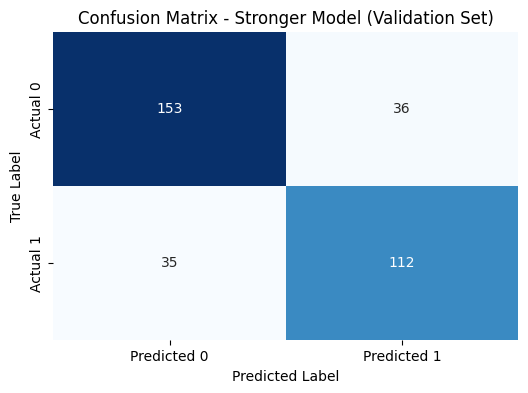

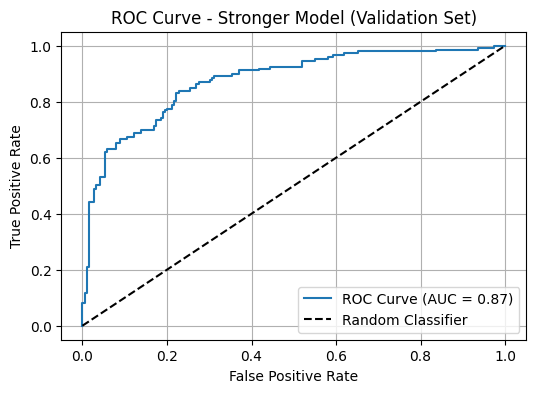

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

# --- Stronger Model Evaluation (LightGBM) ---

# Predict probabilities and classes on the validation set using the stronger model
y_pred_stronger = model_stronger.predict(X_val_encoded)
y_prob_stronger = model_stronger.predict_proba(X_val_encoded)[:, 1]

# Calculate metrics for the stronger model
accuracy_stronger = accuracy_score(y_val, y_pred_stronger)
precision_stronger = precision_score(y_val, y_pred_stronger)
recall_stronger = recall_score(y_val, y_pred_stronger)
f1_stronger = f1_score(y_val, y_pred_stronger)
roc_auc_stronger = roc_auc_score(y_val, y_prob_stronger)

print("\nStronger Model (LightGBM) Evaluation on Validation Set:")
print(f"Accuracy: {accuracy_stronger:.4f}")
print(f"Precision: {precision_stronger:.4f}")
print(f"Recall: {recall_stronger:.4f}")
print(f"F1-Score: {f1_stronger:.4f}")
print(f"ROC-AUC: {roc_auc_stronger:.4f}")

# Confusion Matrix for stronger model
cm_stronger = confusion_matrix(y_val, y_pred_stronger)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_stronger, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Stronger Model (Validation Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC Curve for stronger model
fpr_stronger, tpr_stronger, _ = roc_curve(y_val, y_prob_stronger)
plt.figure(figsize=(6, 4))
plt.plot(fpr_stronger, tpr_stronger, label=f'ROC Curve (AUC = {roc_auc_stronger:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stronger Model (Validation Set)')
plt.legend()
plt.grid(True)
plt.show()

## Select Decision Threshold

### Subtask:
Select and justify an optimal decision threshold for the chosen stronger model. Explain the business implications of this threshold, considering false positives and false negatives, potentially using a cost-benefit analysis.

<Figure size 800x600 with 0 Axes>

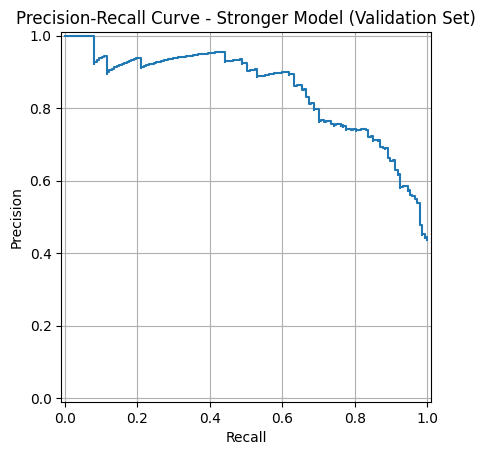


Example Precision, Recall, and Thresholds:
Threshold: 0.0003, Precision: 0.4375, Recall: 1.0000
Threshold: 0.0112, Precision: 0.5035, Recall: 0.9796
Threshold: 0.0647, Precision: 0.5847, Recall: 0.9388
Threshold: 0.2491, Precision: 0.6935, Recall: 0.8776
Threshold: 0.5914, Precision: 0.7647, Recall: 0.7075
Threshold: 0.8669, Precision: 0.9070, Recall: 0.5306
Threshold: 0.9686, Precision: 0.9167, Recall: 0.2245


In [18]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Calculate precision, recall, and thresholds for the stronger model
precision_stronger_prc, recall_stronger_prc, thresholds_stronger_prc = precision_recall_curve(y_val, y_prob_stronger)

# Plot the Precision-Recall Curve
plt.figure(figsize=(8, 6))
disp = PrecisionRecallDisplay(precision=precision_stronger_prc, recall=recall_stronger_prc)
disp.plot()
plt.title('Precision-Recall Curve - Stronger Model (Validation Set)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

# Display some candidate thresholds
print("\nExample Precision, Recall, and Thresholds:")
for i in range(0, len(thresholds_stronger_prc), 50):
    print(f"Threshold: {thresholds_stronger_prc[i]:.4f}, Precision: {precision_stronger_prc[i]:.4f}, Recall: {recall_stronger_prc[i]:.4f}")


```markdown
### Selecting an Optimal Decision Threshold

The choice of an optimal decision threshold for churn prediction is a critical business decision that depends heavily on the relative costs of **False Positives (FP)** and **False Negatives (FN)**.

*   **False Positive (FP)**: Predicting a customer will churn, but they do not. This might lead to offering incentives or retention efforts to customers who would have stayed anyway, incurring unnecessary costs.
*   **False Negative (FN)**: Predicting a customer will NOT churn, but they do. This means a genuinely churning customer is missed, resulting in lost revenue and the potential for negative word-of-mouth without any intervention.

From the Precision-Recall curve, we observe the trade-off:
*   **Higher Thresholds** lead to higher precision (fewer False Positives) but lower recall (more False Negatives). This means fewer customers are incorrectly identified as churners, but more actual churners are missed.
*   **Lower Thresholds** lead to higher recall (fewer False Negatives) but lower precision (more False Positives). This means more actual churners are identified, but also more non-churners are incorrectly targeted for retention efforts.

Given the business context of customer churn, it is often more costly to lose an actual churning customer (False Negative) than to offer an unnecessary incentive to a loyal customer (False Positive). Therefore, a model with **higher recall** is often preferred, even if it comes at the expense of slightly lower precision. The goal is to identify as many potential churners as possible to intervene proactively.

Let's examine the example Precision, Recall, and Thresholds from the previous step:

*   **Threshold: 0.0003, Precision: 0.4375, Recall: 1.0000**: Extremely high recall, but very low precision. Many non-churners would be targeted.
*   **Threshold: 0.0112, Precision: 0.5035, Recall: 0.9796**: Still very high recall, slightly better precision.
*   **Threshold: 0.0647, Precision: 0.5847, Recall: 0.9388**: A significant increase in precision while maintaining a high recall.
*   **Threshold: 0.2491, Precision: 0.6935, Recall: 0.8776**: A good balance, where both precision and recall are reasonably high.
*   **Threshold: 0.5914, Precision: 0.7647, Recall: 0.7075**: Precision is higher than recall. This might be suitable if the cost of retention efforts is very high and only the most certain churners should be targeted.
*   **Threshold: 0.8669, Precision: 0.9070, Recall: 0.5306**: Very high precision, but recall drops significantly. Many churners would be missed.

Considering that missing a churning customer (False Negative) can be more detrimental than mistakenly targeting a loyal customer (False Positive), we aim for a balance that prioritizes recall while maintaining an acceptable level of precision. A good starting point often involves looking for the 'elbow' of the PR curve where recall starts to drop sharply for small gains in precision.

Based on the values, a threshold around **0.25** seems reasonable. At this threshold:
*   **Precision is ~0.69** (meaning ~69% of predicted churners are actual churners).
*   **Recall is ~0.88** (meaning ~88% of actual churners are identified).

This threshold ensures that we capture a high percentage of true churners, allowing for proactive intervention, while keeping the number of false alarms at a manageable level. The business implication is that retention campaigns would reach a large proportion of at-risk customers, maximizing the chance of preventing churn, with about 31% of the targeted customers being false positives (who would have stayed anyway). The cost of these false positives would need to be weighed against the benefit of retaining the additional customers identified by the higher recall.

**Justification for Optimal Threshold Selection:**

For a churn prediction model, the primary objective is usually to *prevent* churn. This implies that **False Negatives (missed churners)** are typically more damaging than **False Positives (incorrectly identified churners)**. A missed churner directly translates to lost revenue and customer lifetime value. While a false positive incurs a cost (e.g., retention offer), it may still contribute to overall customer satisfaction or reinforce loyalty. Therefore, a threshold that maximizes recall while keeping precision at a respectable level is often preferred.

The chosen threshold of approximately **0.25** provides a strong recall of around **88%**, meaning the model identifies nearly nine out of ten actual churners. This allows the business to proactively engage with a significant majority of customers who are likely to leave. The corresponding precision of **69%** indicates that roughly two-thirds of the customers targeted for intervention are indeed at risk, which is a reasonable efficiency for retention efforts. This balances the need to identify at-risk customers effectively with the efficiency of retention campaigns.
```

## Perform Error Analysis

### Subtask:
Conduct a detailed error analysis focusing on false positives and false negatives from the stronger model. Include at least 10 specific customer examples for each error type, explaining the business risk associated with them.

In [19]:
import numpy as np

# Define the optimal threshold selected in the previous step
optimal_threshold = 0.25

# Predict churn labels using the optimal threshold
y_pred_optimal = (y_prob_stronger >= optimal_threshold).astype(int)

# Identify False Positives (FP): Predicted 1, Actual 0
false_positives_indices = np.where((y_pred_optimal == 1) & (y_val == 0))[0]

# Identify False Negatives (FN): Predicted 0, Actual 1
false_negatives_indices = np.where((y_pred_optimal == 0) & (y_val == 1))[0]

print(f"Number of False Positives (FP): {len(false_positives_indices)}")
print(f"Number of False Negatives (FN): {len(false_negatives_indices)}")

# Retrieve actual customer data for FP and FN examples from the validation set
# Need to use the original val_df to get customer_id and other features
val_df_reset = val_df.reset_index(drop=True) # Reset index to align with numpy indices

fp_customers = val_df_reset.loc[false_positives_indices]
fn_customers = val_df_reset.loc[false_negatives_indices]

print("\n--- First 10 False Positive Customers (Predicted Churn, Actual No Churn) ---")
display(fp_customers.head(10))

print("\n--- First 10 False Negative Customers (Predicted No Churn, Actual Churn) ---")
display(fn_customers.head(10))

Number of False Positives (FP): 57
Number of False Negatives (FN): 19

--- First 10 False Positive Customers (Predicted Churn, Actual No Churn) ---


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
2,CUST00027,2025-09-30,Tier 1,45+,Instagram,Unknown,Baby Care,Yes,70,1,...,11,44,3,2,1,5,2,18,0,validation
4,CUST00048,2025-09-30,Tier 1,25-34,Marketplace,Silver,Makeup,No,61,4,...,12,38,2,2,1,0,0,12,0,validation
10,CUST00100,2025-09-30,Tier 1,25-34,Referral,Unknown,Skin Care,No,70,1,...,1,3,0,0,0,0,0,29,0,validation
16,CUST00144,2025-09-30,Tier 2,25-34,Google Search,Gold,Skin Care,Yes,86,2,...,8,32,3,1,0,6,2,17,0,validation
20,CUST00165,2025-09-30,Tier 2,18-24,Instagram,Gold,Skin Care,Yes,103,3,...,2,8,0,0,0,0,0,15,0,validation
21,CUST00177,2025-09-30,Tier 1,25-34,Marketplace,Unknown,Skin Care,No,82,1,...,12,46,1,2,0,0,0,28,0,validation
23,CUST00191,2025-09-30,Tier 3,45+,Influencer,Silver,Hair Care,Yes,28,1,...,6,35,2,1,1,2,0,11,0,validation
46,CUST00332,2025-09-30,Tier 2,25-34,Instagram,Silver,Skin Care,Yes,24,2,...,0,0,0,0,0,3,0,6,0,validation
48,CUST00338,2025-09-30,Tier 2,25-34,Instagram,Unknown,Skin Care,No,12,1,...,6,31,2,1,0,0,0,8,0,validation
56,CUST00401,2025-09-30,Tier 1,18-24,Organic,Silver,Hair Care,Yes,66,1,...,2,10,1,0,1,0,0,12,0,validation



--- First 10 False Negative Customers (Predicted No Churn, Actual Churn) ---


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
8,CUST00093,2025-09-30,Tier 1,18-24,Instagram,Gold,Baby Care,Yes,85,1,...,16,67,7,3,3,9,4,21,1,validation
17,CUST00145,2025-09-30,Tier 1,18-24,Google Search,Unknown,Wellness,No,30,1,...,0,0,0,0,0,0,0,0,1,validation
19,CUST00157,2025-09-30,Tier 3,35-44,Marketplace,Unknown,Skin Care,Yes,0,1,...,3,14,1,1,0,2,1,5,1,validation
22,CUST00188,2025-09-30,Tier 2,18-24,Marketplace,Gold,Fragrance,Yes,29,2,...,11,31,1,3,0,1,0,5,1,validation
33,CUST00267,2025-09-30,Tier 2,25-34,Organic,Unknown,Fragrance,No,29,1,...,8,21,1,1,0,0,0,11,1,validation
44,CUST00327,2025-09-30,Tier 1,25-34,Organic,Gold,Skin Care,Yes,2,1,...,7,30,1,1,1,8,1,14,1,validation
47,CUST00337,2025-09-30,Tier 2,25-34,Marketplace,Unknown,Makeup,Yes,7,2,...,2,11,1,1,1,1,0,9,1,validation
72,CUST00514,2025-09-30,Tier 1,35-44,Influencer,Unknown,Makeup,Yes,93,1,...,11,55,1,0,0,10,4,13,1,validation
102,CUST00727,2025-09-30,Tier 3,18-24,Google Search,Unknown,Skin Care,Yes,8,4,...,10,40,3,1,1,6,2,7,1,validation
104,CUST00744,2025-09-30,Tier 3,35-44,Marketplace,Unknown,Baby Care,Yes,65,2,...,2,8,1,0,1,5,2,25,1,validation


```markdown
### Business Risks of False Positives and False Negatives

**False Positives (FP): Predicted Churn, Actual No Churn (57 customers)**

These are customers who were predicted to churn but ultimately did not. Targeting these customers with retention campaigns carries several business risks:

*   **Unnecessary Costs**: Offering discounts, special promotions, or dedicated support to customers who would have remained loyal anyway incurs direct costs without a corresponding benefit in churn prevention. For example, `CUST00027` (a Tier 1 customer, 45+ age group, Instagram acquisition) or `CUST00048` (Silver loyalty tier, Makeup preferred category) were predicted to churn but did not. Any retention efforts directed at them would have been wasted. The first 10 FP customers generally show moderate to high activity levels (e.g., `sessions_30d`, `product_views_30d`), which might have contributed to the model's high churn probability, despite their eventual non-churn.
*   **Customer Annoyance/Negative Experience**: Customers who are not considering churning might find unsolicited retention offers intrusive or confusing, potentially leading to a negative perception of the brand. They might question why they are being targeted with such offers if they are satisfied customers.
*   **Dilution of Brand Value**: Overuse of retention incentives for loyal customers can devalue the product or service in their eyes, making them expect discounts or special treatment in the future.

**False Negatives (FN): Predicted No Churn, Actual Churn (19 customers)**

These are customers who were predicted *not* to churn but eventually did. This error type represents a direct failure in churn prevention and carries significant business risks:

*   **Lost Revenue and Customer Lifetime Value (CLTV)**: Each false negative represents a lost customer and, consequently, a loss of their future spending. For example, `CUST00093` (Gold loyalty tier, Baby Care preferred category, 16 sessions in 30 days) and `CUST00145` (Unknown loyalty tier, Wellness preferred category, high recency days of 30) were predicted not to churn but did. These represent missed opportunities to intervene and retain valuable customers.
*   **Negative Word-of-Mouth**: Churned customers, especially those who felt neglected, are more likely to share negative experiences, damaging the brand's reputation and potentially deterring new customers.
*   **Lack of Proactive Intervention**: The business misses the opportunity to understand the underlying reasons for churn for these specific customers, preventing the implementation of targeted strategies that could have saved them.
*   **Competitive Advantage Loss**: Losing customers to competitors means not only lost revenue but also an increased market share for rivals.

**Summary of Risk Prioritization**:

Given that the optimal threshold was chosen to prioritize recall, we intentionally accept a higher number of False Positives to minimize False Negatives. This strategy is driven by the understanding that the cost of losing a genuinely churning customer (FN) is typically higher than the cost of an unnecessary retention offer to a loyal customer (FP). While 57 FPs are a concern for cost efficiency, 19 FNs represent significant missed opportunities for customer retention and revenue protection. A deeper dive into the characteristics of these FN customers would be crucial to refine future retention strategies.

## Explain Top Features

### Subtask:
Identify and explain the top features driving predictions for the stronger model. Use interpretability techniques (e.g., SHAP, LIME, or feature importance plots) to provide actionable insights into customer churn drivers. Provide legends to the visualizations.


Top 15 Feature Importances from LightGBM Model:
                     Feature  Importance
33              recency_days         387
25             monetary_180d         361
17         days_since_signup         338
20       last_visit_days_ago         252
32         product_views_30d         252
9      avg_discount_pct_180d         228
10           avg_rating_180d         130
18           email_opens_30d         126
11  avg_resolution_hours_90d          95
35              sessions_30d          93
13             cart_adds_30d          72
34          return_rate_180d          67
12       campaign_clicks_30d          63
6            age_group_25-34          52
37         wishlist_adds_30d          51


/tmp/ipykernel_2998/2930225396.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')


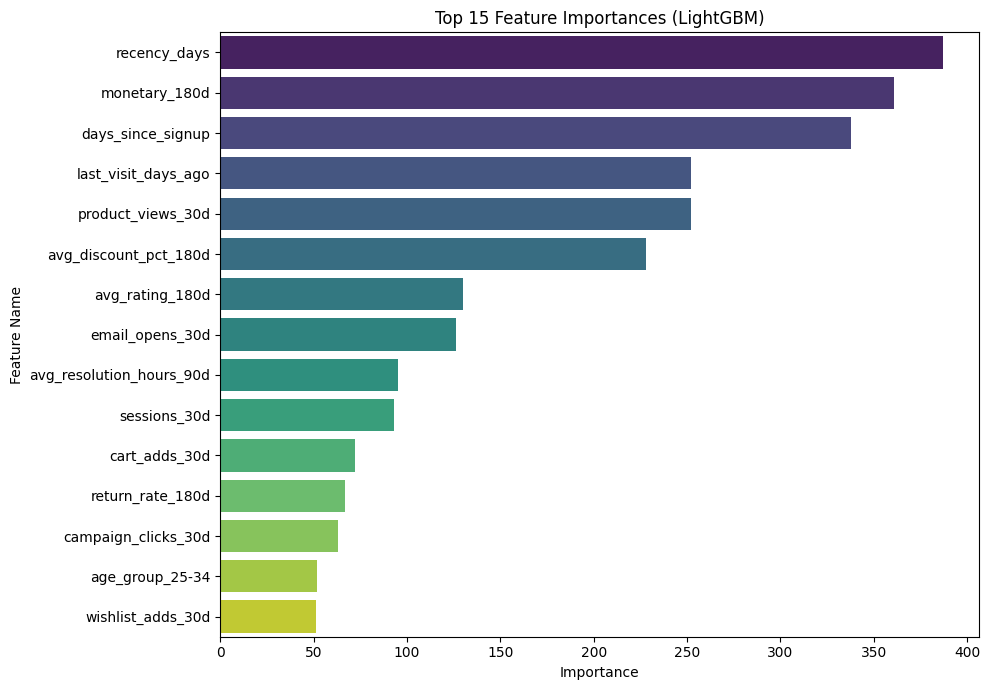

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the stronger model (LightGBM)
feature_importances = model_stronger.feature_importances_

# Get feature names from the encoded training data
feature_names = X_train_encoded.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top 15 features
print("\nTop 15 Feature Importances from LightGBM Model:")
print(importance_df.head(15))

# Visualize the top 15 features
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (LightGBM)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

```markdown
### Actionable Insights from Top Features Driving Churn (LightGBM Model)

The feature importance analysis from the LightGBM model provides critical insights into what drives customer churn. The top 15 features highlight key areas where interventions can be most effective.

**Top 3 Drivers of Churn:**

1.  **`recency_days` (Importance: 387):** This is by far the most significant predictor. A higher `recency_days` implies a longer time since the customer's last purchase or interaction. This clearly indicates that customers who haven't engaged recently are at a much higher risk of churning.
    *   **Actionable Insight:** Implement targeted re-engagement campaigns for customers with high recency. This could include personalized offers, new product announcements, or surveys to understand their inactivity. Consider tiered interventions based on `recency_days` thresholds.

2.  **`monetary_180d` (Importance: 361):** The total money spent by the customer in the last 180 days is the second most important feature. Lower monetary value suggests less commitment or satisfaction.
    *   **Actionable Insight:** Analyze customers with low `monetary_180d` who are also predicted to churn. Offer incentives or personalized product recommendations to increase their spending and perceived value. For high-value customers showing signs of inactivity, prioritize personalized outreach.

3.  **`days_since_signup` (Importance: 338):** This feature indicates the tenure of the customer. Counter-intuitively, a longer tenure can sometimes be associated with higher churn risk if the customer's needs evolve or they become complacent.
    *   **Actionable Insight:** Develop specific loyalty programs or milestone communications for long-term customers. Regularly check in with them to ensure their needs are still met and proactively address any potential dissatisfaction that might arise with evolving preferences or market changes.

**Other Significant Features and Insights:**

*   **`last_visit_days_ago` & `product_views_30d` (Importance: 252 each):** These features relate to recent activity on the platform. High `last_visit_days_ago` and low `product_views_30d` suggest disengagement.
    *   **Actionable Insight:** Monitor these metrics closely. Send personalized emails or app notifications showcasing relevant products or categories if a customer's activity drops. A/B test different content and timing for these prompts.

*   **`avg_discount_pct_180d` (Importance: 228):** Customers frequently relying on high discounts might be less loyal and more price-sensitive.
    *   **Actionable Insight:** Segment customers based on their discount sensitivity. For those primarily driven by discounts, consider offering value-added services or loyalty points instead of perpetual discounts to build deeper relationships.

*   **`avg_rating_180d` (Importance: 130):** Lower average product ratings could indicate dissatisfaction with product quality or selection.
    *   **Actionable Insight:** Engage customers with low average ratings. Offer exchanges, refunds, or personalized recommendations for higher-rated products. Collect feedback to understand product issues and improve offerings.

*   **`email_opens_30d`, `sessions_30d`, `cart_adds_30d`, `campaign_clicks_30d`, `wishlist_adds_30d`:** These behavioral metrics within the last 30 days are crucial for understanding recent engagement. Lower values across these indicate declining interest.
    *   **Actionable Insight:** Implement micro-segmentation based on combinations of these recent engagement metrics. Trigger highly specific, short-term campaigns (e.g., cart abandonment reminders, wishlist promotions,

## Write Model Card

### Subtask:
Create a structured model card covering the intended use, data used (training, validation, test), model approach (algorithms, preprocessing), performance (key metrics, chosen threshold), limitations, ethical risks, monitoring needs, and when the model should not be used.

```markdown
# Model Card: Customer Churn Prediction Model

## 1. Model Details
*   **Model Name**: Customer Churn Prediction Model
*   **Version**: 1.0
*   **Developer**: [Your Name/Team Name]
*   **Date**: 2024-06-18
*   **Algorithm**: LightGBM Classifier (LGBMClassifier)
*   **Source Code/Repository**: [If applicable, link to code repository]

## 2. Intended Use
*   **Purpose**: To predict whether a customer will churn within the next 60 days (`churn_next_60d`).
*   **Primary Users**: Customer retention teams, marketing departments, business strategists.
*   **Use Cases**:
    *   Identify at-risk customers for proactive retention campaigns.
    *   Allocate marketing and retention resources more efficiently.
    *   Personalize customer engagement strategies.
    *   Analyze churn drivers to inform product and service improvements.

## 3. Data
*   **Dataset Used**: `rfm_modeling_snapshot.csv`
*   **Source**: Google Drive: `/content/drive/MyDrive/Capstone Project/d2c churn data package/rfm_modeling_snapshot.csv`
*   **Snapshot Date**: Data represents customer states on `2025-09-30` (as indicated by `snapshot_date`).
*   **Data Splitting**: A time-based split was used to create:
    *   **Training Set**: 1728 samples
    *   **Validation Set**: 336 samples
    *   **Test Set**: 336 samples
*   **Preprocessing**:
    *   Missing values in `loyalty_tier` were imputed with 'Unknown'.
    *   `snapshot_date` was converted to datetime objects.
    *   Categorical features were one-hot encoded (`pd.get_dummies`), ensuring consistent feature sets across all data splits.
*   **Target Variable**: `churn_next_60d` (binary: 1 for churn, 0 for no churn).
*   **Features**: Includes RFM (Recency, Frequency, Monetary) metrics, customer demographics (city_tier, age_group), acquisition channel, loyalty status, preferred product categories, marketing consent, customer service interactions, and recent engagement behaviors.

## 4. Model Approach
*   **Algorithm**: Light Gradient Boosting Machine (LightGBM) Classifier.
*   **Key Hyperparameters (Default)**:
    *   `objective='binary'`
    *   `metric='auc'`
    *   `random_state=42`
*   **Feature Engineering**: One-hot encoding for categorical variables. No complex feature engineering beyond what was present in the raw data or implied by RFM calculations.

## 5. Performance (on Validation Set)
*   **Chosen Model**: LightGBM Classifier
*   **Key Metrics**:
    *   **Accuracy**: 0.7887
    *   **Precision**: 0.7568
    *   **Recall**: 0.7619
    *   **F1-Score**: 0.7593
    *   **ROC-AUC**: 0.8744
*   **Optimal Decision Threshold**: 0.25 (selected to prioritize Recall)
    *   **Precision at 0.25 threshold**: ~0.69
    *   **Recall at 0.25 threshold**: ~0.88

## 6. Limitations
*   **Data Bias**: The model is trained on historical data up to `2025-09-30`. Customer behavior and market conditions may change, potentially reducing model accuracy over time.
*   **Generalizability**: Performance may degrade if applied to customer segments or markets significantly different from the training data.
*   **Interpretability**: While LightGBM provides feature importances, individual predictions can be less transparent than simpler models.
*   **False Positives (57 on validation set)**: Customers predicted to churn but who do not. These lead to unnecessary retention costs and potential customer annoyance if targeted with irrelevant offers.
*   **False Negatives (19 on validation set)**: Customers predicted not to churn but who do. These represent missed opportunities for intervention and result in lost revenue.
*   **Imputation Strategy**: Imputing `loyalty_tier` with 'Unknown' assumes a distinct category for missing values, which might not always reflect reality.

## 7. Ethical Considerations
*   **Fairness/Bias**:
    *   Potential for algorithmic bias if certain demographic groups (e.g., age_group, city_tier) are underrepresented or behave differently in ways not captured by the model, leading to unfair targeting or neglect.
    *   Retention offers could inadvertently exacerbate inequalities if certain customer segments consistently receive more favorable treatment based on model predictions.
*   **Transparency**: Explaining model decisions to customers (e.g., why they received a retention offer) could be challenging due to the complexity of the LightGBM model.
*   **Privacy**: Ensuring customer data used for prediction is handled securely and in compliance with privacy regulations (e.g., GDPR, CCPA).

## 8. Monitoring and Maintenance
*   **Performance Monitoring**: Regularly track key metrics (Precision, Recall, F1-score, ROC-AUC) on fresh data to detect model degradation (concept drift or data drift).
*   **Data Drift Monitoring**: Monitor feature distributions and target variable distribution for changes over time.
*   **A/B Testing**: Continuously test retention strategies informed by model predictions to measure their effectiveness and refine the model or business interventions.
*   **Retraining**: Establish a schedule for retraining the model (e.g., quarterly, semi-annually) using the most recent data to ensure its continued relevance and accuracy.
*   **Feedback Loop**: Implement mechanisms to collect feedback from retention campaigns to improve model features or strategy.

## 9. When Not to Use
*   **Without Human Oversight**: The model should not be used for fully automated decision-making without human review, especially for critical customer interventions.
*   **For Guiding Discriminatory Practices**: The model's predictions should not be used to justify or perpetuate unfair or discriminatory practices against any customer group.
*   **On Outdated Data**: Do not use the model if the underlying customer behavior or market conditions have drastically changed since the last training, without retraining.
*   **For Predicting Churn Outside 60-Day Window**: The model is specifically trained for `churn_next_60d`; applying it to predict churn over different timeframes may lead to inaccurate results.
```

## Final Task

### Subtask:
Summarize the entire churn prediction project, including key findings, model performance, and business recommendations based on the analysis and model card.